Loading Iris Dataset...

Dataset Shape: (150, 5)
Column Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

FIRST 5 ROWS
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm

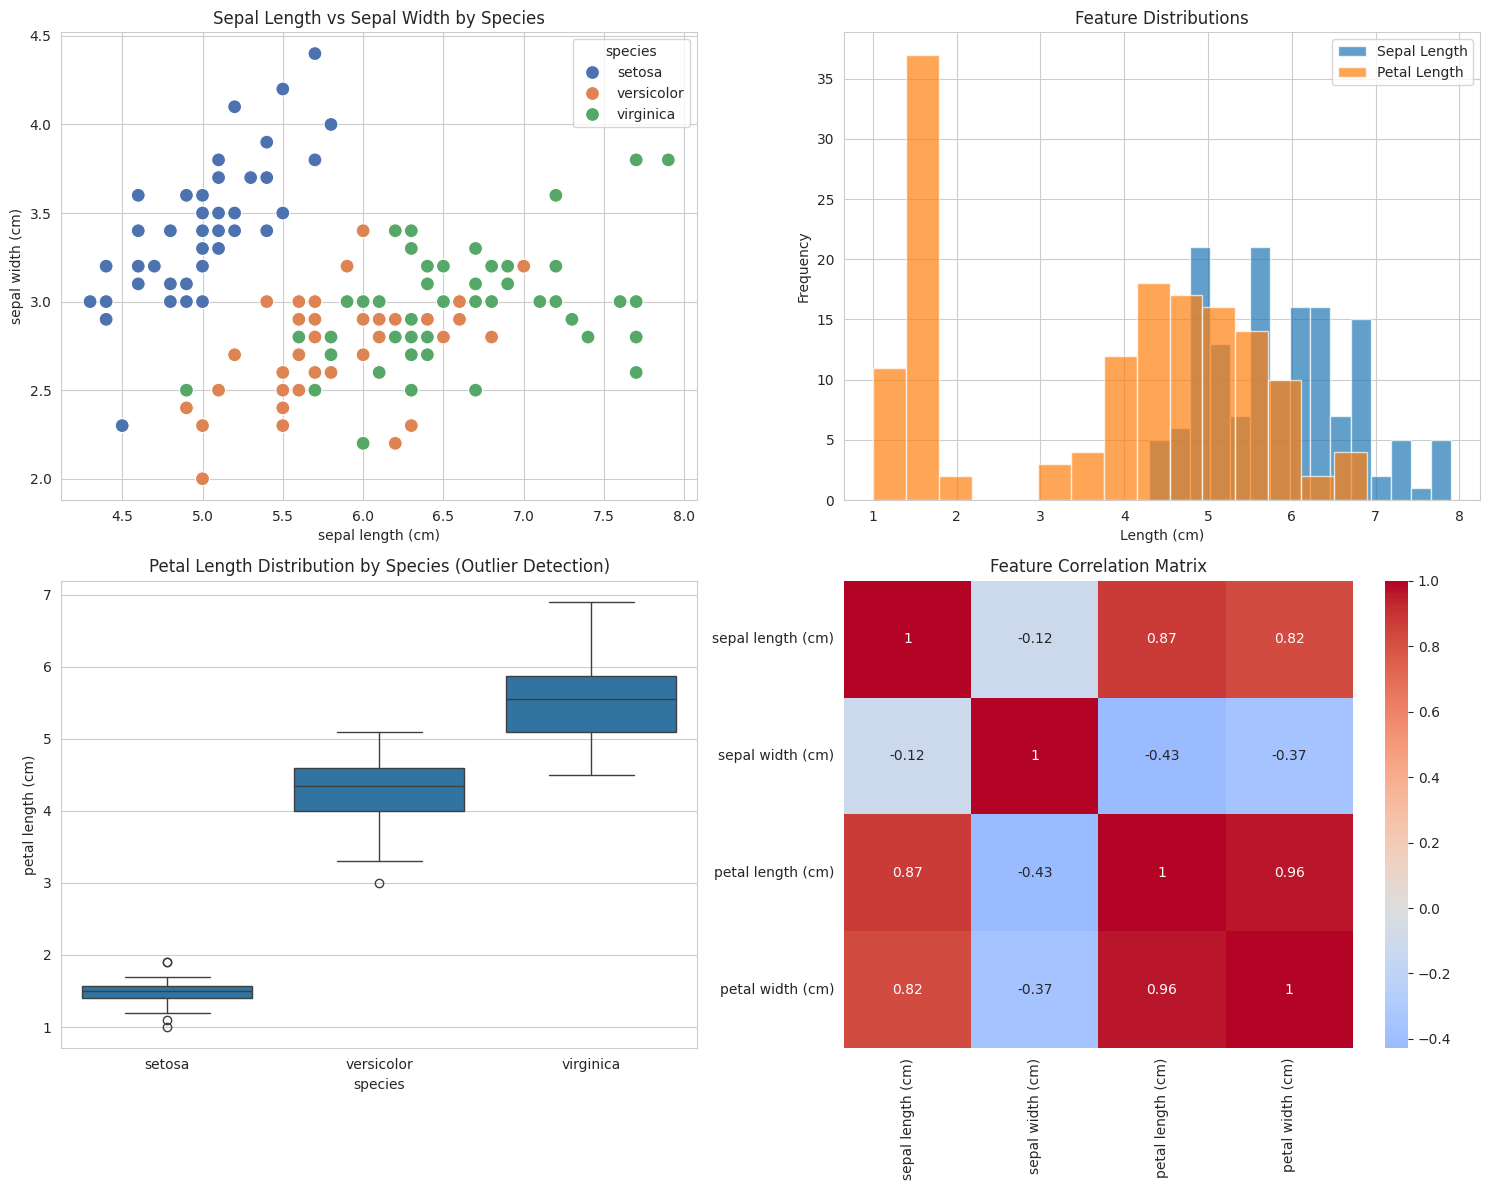

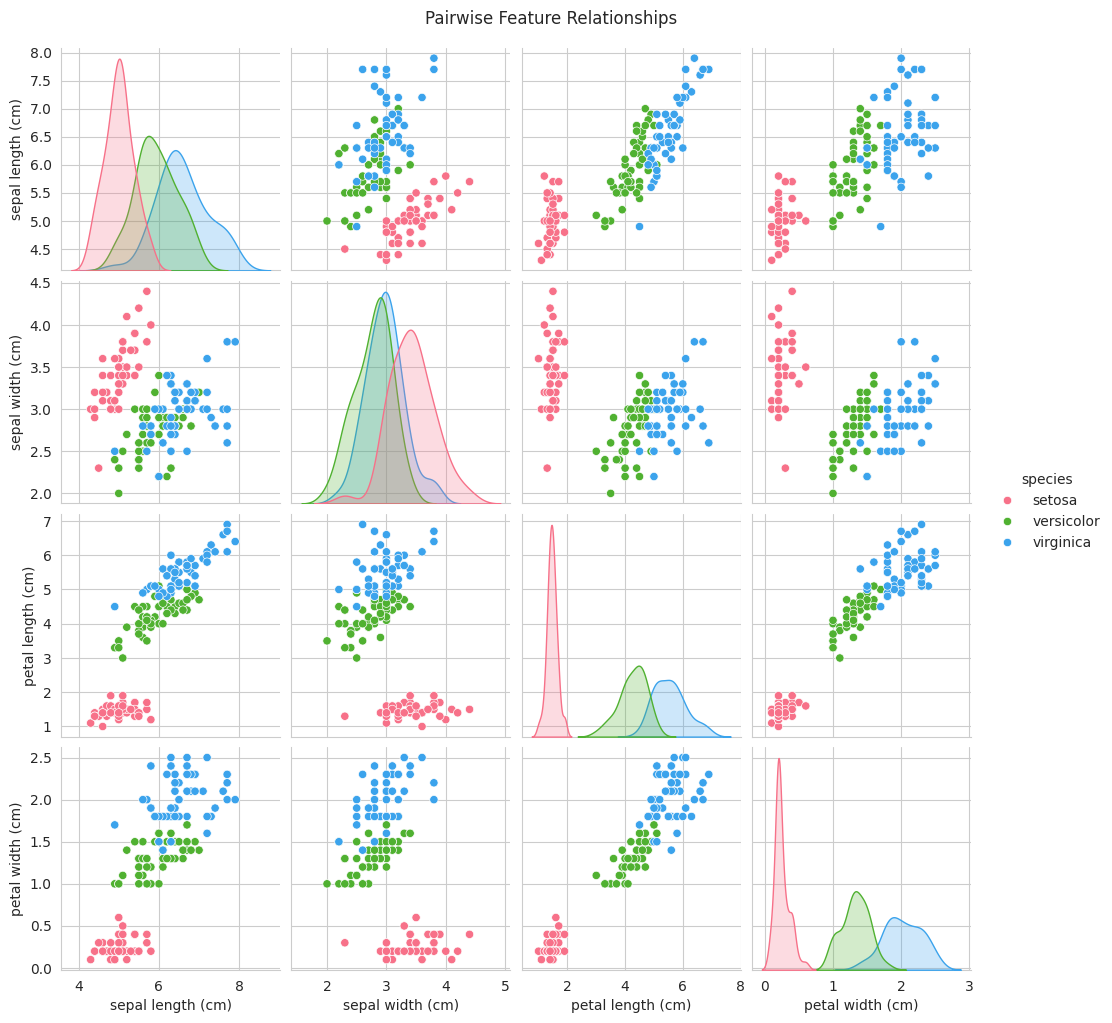


Key Insights:
- Dataset contains 150 samples with 4 features
- No missing values detected
- Petal length/width show strong correlation with species
- Setosa is linearly separable from other species


In [1]:
# task1_iris_eda.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris



# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load Dataset
print("Loading Iris Dataset...")
# Method 1: From sklearn
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

# Method 2: Alternatively via seaborn
# df = sns.load_dataset('iris')

print(f"\nDataset Shape: {df.shape}")
print(f"Column Names: {list(df.columns)}")

# 2. Initial Inspection
print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("DATASET INFO")
print("="*50)
df.info()

print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(df.describe())

# 3. Visualizations
fig = plt.figure(figsize=(15, 12))

# Scatter plot - Pairplot for relationships
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)',
                hue='species', palette='deep', s=100)
plt.title('Sepal Length vs Sepal Width by Species')

# Histograms - Distribution of features
plt.subplot(2, 2, 2)
df['sepal length (cm)'].hist(bins=15, alpha=0.7, label='Sepal Length')
df['petal length (cm)'].hist(bins=15, alpha=0.7, label='Petal Length')
plt.xlabel('Length (cm)')
plt.ylabel('Frequency')
plt.title('Feature Distributions')
plt.legend()

# Box plots - Outlier detection
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='species', y='petal length (cm)')
plt.title('Petal Length Distribution by Species (Outlier Detection)')

# Correlation heatmap
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('iris_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional: Pairplot for comprehensive relationships
pairplot = sns.pairplot(df, hue='species', palette='husl', height=2.5)
pairplot.fig.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

print("\nKey Insights:")
print(f"- Dataset contains {df.shape[0]} samples with {df.shape[1]-1} features")
print(f"- No missing values detected")
print(f"- Petal length/width show strong correlation with species")
print(f"- Setosa is linearly separable from other species")

task 2

Loading Heart Disease Dataset...
Original shape: (303, 14)
Missing values: 0
Cleaned shape: (297, 14)

Class distribution:
target
0    160
1    137
Name: count, dtype: int64


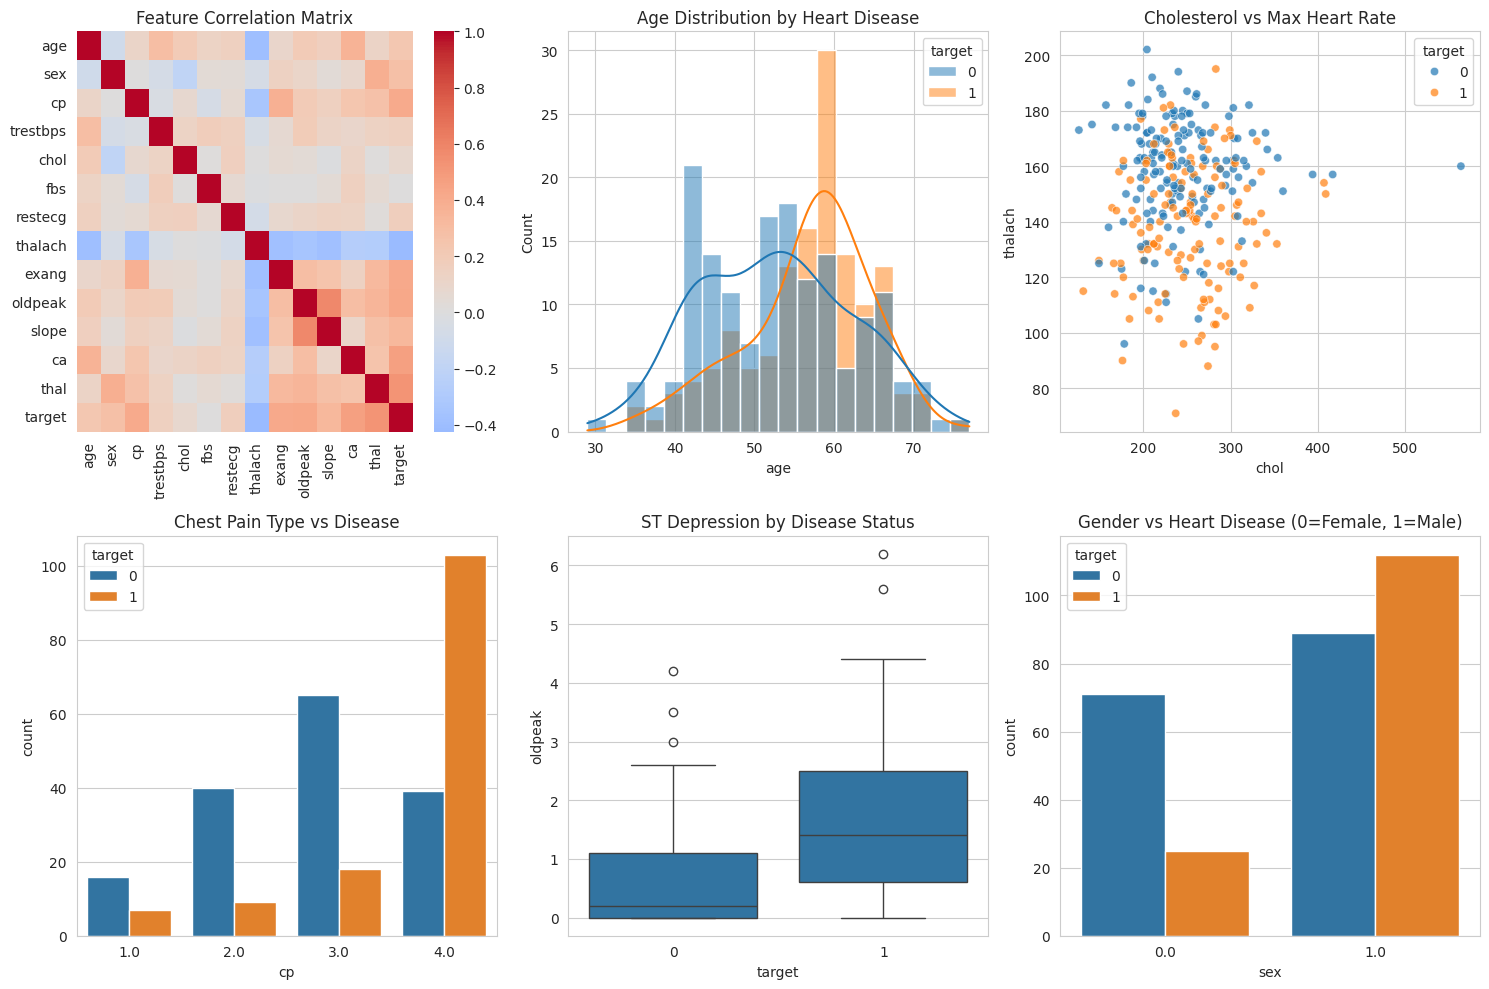


Training Logistic Regression
Accuracy: 0.8333
AUC-ROC: 0.9498

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


Training Decision Tree
Accuracy: 0.7000
AUC-ROC: 0.7450

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.68      0.84      0.75        32
     Disease       0.75      0.54      0.62        28

    accuracy                           0.70        60
   macro avg       0.71      0.69      0.69        60
weighted avg       0.71      0.70      0.69        60



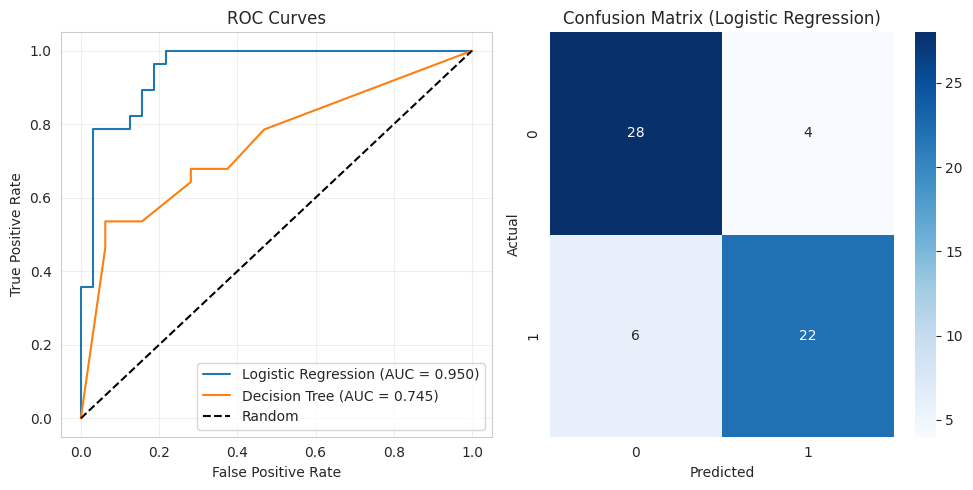


FEATURE IMPORTANCE ANALYSIS

Logistic Regression (Absolute Coefficients):
     feature  importance
11        ca    0.958461
12      thal    0.738613
2         cp    0.507960
1        sex    0.484582
9    oldpeak    0.444296
3   trestbps    0.420218
8      exang    0.372644
10     slope    0.352973
5        fbs    0.331039
6    restecg    0.303674

Decision Tree Feature Importance:
     feature  importance
12      thal    0.365042
2         cp    0.215190
4       chol    0.119210
11        ca    0.105255
9    oldpeak    0.076771
3   trestbps    0.070938
7    thalach    0.024002
0        age    0.023591
1        sex    0.000000
8      exang    0.000000


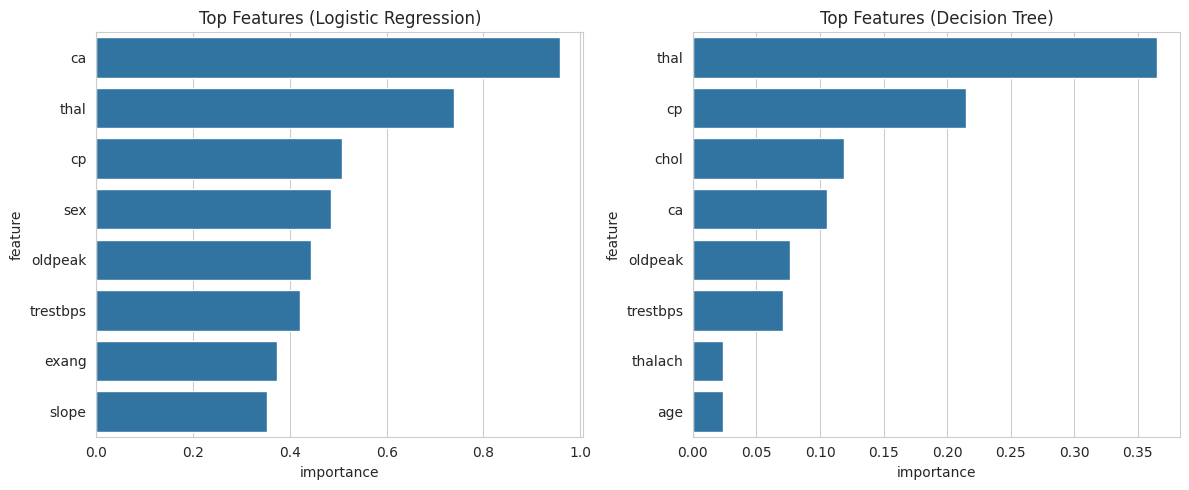

In [3]:
# task3_heart_disease.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve,
                             roc_auc_score, auc)
import warnings
warnings.filterwarnings('ignore')

# Load dataset (assuming downloaded from Kaggle UCI Heart Disease)
# Alternative: Use raw URL or local path
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak',
                'slope', 'ca', 'thal', 'target']

print("Loading Heart Disease Dataset...")
df = pd.read_csv(url, names=column_names)

# Data Cleaning
print(f"Original shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Handle missing values (denoted as '?' in this dataset)
df = df.replace('?', np.nan)
df = df.dropna()
df = df.astype(float)

# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = (df['target'] > 0).astype(int)

print(f"Cleaned shape: {df.shape}")
print(f"\nClass distribution:\n{df['target'].value_counts()}")

# EDA
plt.figure(figsize=(15, 10))

# Correlation matrix
plt.subplot(2, 3, 1)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

# Age distribution by target
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True)
plt.title('Age Distribution by Heart Disease')

# Cholesterol vs Max Heart Rate
plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='chol', y='thalach', hue='target', alpha=0.7)
plt.title('Cholesterol vs Max Heart Rate')

# Chest pain type distribution
plt.subplot(2, 3, 4)
sns.countplot(data=df, x='cp', hue='target')
plt.title('Chest Pain Type vs Disease')

# Box plot for oldpeak
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='target', y='oldpeak')
plt.title('ST Depression by Disease Status')

# Gender distribution
plt.subplot(2, 3, 6)
sns.countplot(data=df, x='sex', hue='target')
plt.title('Gender vs Heart Disease (0=Female, 1=Male)')

plt.tight_layout()
plt.savefig('heart_disease_eda.png', dpi=300, bbox_inches='tight')
plt.show()

# Model Training
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print('='*50)

    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'auc': auc_score,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# ROC Curves
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# Confusion Matrix for best model (Logistic Regression usually)
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, results['Logistic Regression']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('heart_disease_model.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Logistic Regression coefficients
lr_model = results['Logistic Regression']['model']
feature_importance_lr = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(lr_model.coef_[0])
}).sort_values('importance', ascending=False)

print("\nLogistic Regression (Absolute Coefficients):")
print(feature_importance_lr.head(10))

# Decision Tree feature importance
dt_model = results['Decision Tree']['model']
feature_importance_dt = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nDecision Tree Feature Importance:")
print(feature_importance_dt.head(10))

# Plot top features
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=feature_importance_lr.head(8), x='importance', y='feature')
plt.title('Top Features (Logistic Regression)')

plt.subplot(1, 2, 2)
sns.barplot(data=feature_importance_dt.head(8), x='importance', y='feature')
plt.title('Top Features (Decision Tree)')

plt.tight_layout()
plt.show()